## Hector Pena
## Project Milestone 2
## DSC 540

### Below is the dataset cleaning and extraction for the first set of data being the CSV file found on Kaggle, this dataset was sourced from a legit website that provides different type of datasets to use in the education sector as-well-as in the private sector. At a first glance at my dataset there are a lot of unnecesarry information that needs to be removed and a lot of information that is inputed in the same coulmn which requires some manipulaiton to have the data show what I need it to show. The ethical dilema I may face with this project is having access to private information regarding injuries at these amuestment parks, luckily the data does not include any identifying factors tagging each incident to a specific individual. Some of my data might be a far reach to correlate with eachother, to combat this, I have focused my project and research to just look at the parameters that benefit my project and will eliminate all other none-essential columns and information in the data.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
df=pd.read_csv('../dsc540/datasets/themepark_incident_data.csv')
df.head()

,Company,Incident_date,Ride_name_dirty,Ride_name,Theme_Park,age_gender,description
0,Disney World,06/09/2022,Alien Swirling Saucers,Alien Swirling Saucers,Hollywood Studios,59 yof,guest with pre-existing condition sustained in...
1,Disney World,10/05/2014,Astro Orbiter,Astro Orbiter,Magic Kingdom,68 yom,"guest fell exiting vehicle, developed blood c..."
2,Disney World,12/03/2009,Astro Orbitor,Astro Orbiter,Magic Kingdom,40 yof,fractured left ankle exiting ride
3,Disney World,08/07/2022,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,83 yom,guest with pre-existing condition was briefly ...
4,Disney World,4/19/22,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,42 yof,guest with pre-existing condition had motion s...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Company          682 non-null    object
 1   Incident_date    682 non-null    object
 2   Ride_name_dirty  682 non-null    object
 3   Ride_name        682 non-null    object
 4   Theme_Park       682 non-null    object
 5   age_gender       682 non-null    object
 6   description      682 non-null    object
dtypes: object(7)
memory usage: 37.4+ KB


In [5]:
df['Company'] = df['Company'].map(lambda x: x.replace(':', ''))

In [6]:
### Step 1 of data transformation
# Convert incident date from object to datetime using mixed format
df['Incident_date'] = pd.to_datetime(df['Incident_date'],format='mixed')

In [7]:
### Step 2 
# strip the age_gender of any whitespace
df['age_gender'] = df['age_gender'].str.strip()
# Use last character of the inoute and use this as gender
df['gender'] = df['age_gender'].str[-1:]

### Step 3
# use the first 2 characters of the column and use this as the age
df['age'] = df['age_gender'].str[:2]

### Step 4
# remove any white space for ages less than 10 years old
df['age'] = df['age'].str.strip().astype(int)

### Step 5
# remove orignal column from dataset
df.drop(columns=['age_gender'], inplace=True)

In [8]:
### display new data set
df.head()

,Company,Incident_date,Ride_name_dirty,Ride_name,Theme_Park,description,gender,age
0,Disney World,2022-06-09,Alien Swirling Saucers,Alien Swirling Saucers,Hollywood Studios,guest with pre-existing condition sustained in...,f,59
1,Disney World,2014-10-05,Astro Orbiter,Astro Orbiter,Magic Kingdom,"guest fell exiting vehicle, developed blood c...",m,68
2,Disney World,2009-12-03,Astro Orbitor,Astro Orbiter,Magic Kingdom,fractured left ankle exiting ride,f,40
3,Disney World,2022-08-07,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,guest with pre-existing condition was briefly ...,m,83
4,Disney World,2022-04-19,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,guest with pre-existing condition had motion s...,f,42


In [9]:
### create 3 different columns which sperate out date into month, day, and year
df['day_of_month'] = df['Incident_date'].dt.day
df['month_of_incident'] = df['Incident_date'].dt.month
df['year_of_incident'] = df['Incident_date'].dt.year

### Below are different categories for each incident type, I have cleaned and manipulated the data to show categories like: deceased, hospital, pre-existing conditon, etc. These categories can help shine light to see if a certain type of condition has a greater chance of getting injured.

In [10]:
def deceased_indicator(desc_text):
    deceased_string = ['passed away', 'died']    
    if any(x in desc_text.lower() for x in deceased_string):
        return 1
    else:
        return 0

df['deceased_ind'] = df['description'].apply(deceased_indicator)
df['deceased_ind'].value_counts()

deceased_ind
0    657
1     25
Name: count, dtype: int64

In [11]:
def hospital_indicator(desc_text):
    if 'hospital' in desc_text.lower():
        return 1
    else:
        return 0

df['hospital_ind'] = df['description'].apply(hospital_indicator)
df['hospital_ind'].value_counts()

hospital_ind
0    664
1     18
Name: count, dtype: int64

In [12]:
def pre_existing_ind(desc_text):
    pre_existing_string = ['pre-existing', 'pre existing'] 
    if any(x in desc_text.lower() for x in pre_existing_string):
        return 1
    else:
        return 0

df['pre_existing_ind'] = df['description'].apply(pre_existing_ind)
df['pre_existing_ind'].value_counts()

pre_existing_ind
0    565
1    117
Name: count, dtype: int64

In [13]:
def unconscious_ind(desc_text):
    unconscious_string = ['unconscious', 'syncope', 'passed out', 'fainted', 'collapsed', 'loss of consciousness', 'unresponsive']    
    if any(x in desc_text.lower() for x in unconscious_string):
        return 1
    else:
        return 0
df['unconscious_ind'] = df['description'].apply(unconscious_ind)
df['unconscious_ind'].value_counts()


unconscious_ind
0    619
1     63
Name: count, dtype: int64

In [14]:
def chest_pain_ind(desc_text):
    cp_string = ['chest pain']    
    if any(x in desc_text.lower() for x in cp_string):
        return 1
    else:
        return 0
df['chest_pain_ind'] = df['description'].apply(chest_pain_ind)
df['chest_pain_ind'].value_counts()

chest_pain_ind
0    599
1     83
Name: count, dtype: int64

In [15]:
def seizure_ind(desc_text):
    seizure_string = ['seizure']    
    if any(x in desc_text.lower() for x in seizure_string):
        return 1
    else:
        return 0
df['seizure_ind'] = df['description'].apply(seizure_ind)
df['seizure_ind'].value_counts()

seizure_ind
0    616
1     66
Name: count, dtype: int64

In [16]:
def physical_ind(desc_text):
    phys_string = ['fell', 'fracture', 'lacerated', 'tear', 'tripped', 'hit', 'laceration', 'fx', 'broke', 'injury', 'broken', 'struck', 'injured', 'hip']    
    if any(x in desc_text.lower() for x in phys_string):
        return 1
    else:
        return 0
df['physical_ind'] = df['description'].apply(physical_ind)
df['physical_ind'].value_counts(), 


(physical_ind
 0    534
 1    148
 Name: count, dtype: int64,)

In [17]:
def sickness_ind(desc_text):
    sickness_string = ['sickness', 'motion sickness', 'dizzy', 'ill', 'not feeling well', 'dizziness', 'vertigo']    
    if any(x in desc_text.lower() for x in sickness_string):
        return 1
    else:
        return 0
df['sickness_ind'] = df['description'].apply(sickness_ind)
df['sickness_ind'].value_counts(), 

(sickness_ind
 0    513
 1    169
 Name: count, dtype: int64,)

In [18]:
df.head()

,Company,Incident_date,Ride_name_dirty,Ride_name,Theme_Park,description,gender,age,day_of_month,month_of_incident,year_of_incident,deceased_ind,hospital_ind,pre_existing_ind,unconscious_ind,chest_pain_ind,seizure_ind,physical_ind,sickness_ind
0,Disney World,2022-06-09,Alien Swirling Saucers,Alien Swirling Saucers,Hollywood Studios,guest with pre-existing condition sustained in...,f,59,9,6,2022,0,0,1,0,0,0,1,0
1,Disney World,2014-10-05,Astro Orbiter,Astro Orbiter,Magic Kingdom,"guest fell exiting vehicle, developed blood c...",m,68,5,10,2014,0,0,0,0,0,0,1,0
2,Disney World,2009-12-03,Astro Orbitor,Astro Orbiter,Magic Kingdom,fractured left ankle exiting ride,f,40,3,12,2009,0,0,0,0,0,0,1,0
3,Disney World,2022-08-07,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,guest with pre-existing condition was briefly ...,m,83,7,8,2022,0,0,1,1,0,0,0,0
4,Disney World,2022-04-19,Avatar Flight of Passage,Avatar Flight of Passage,Animal Kingdom,guest with pre-existing condition had motion s...,f,42,19,4,2022,0,0,1,0,0,0,0,1


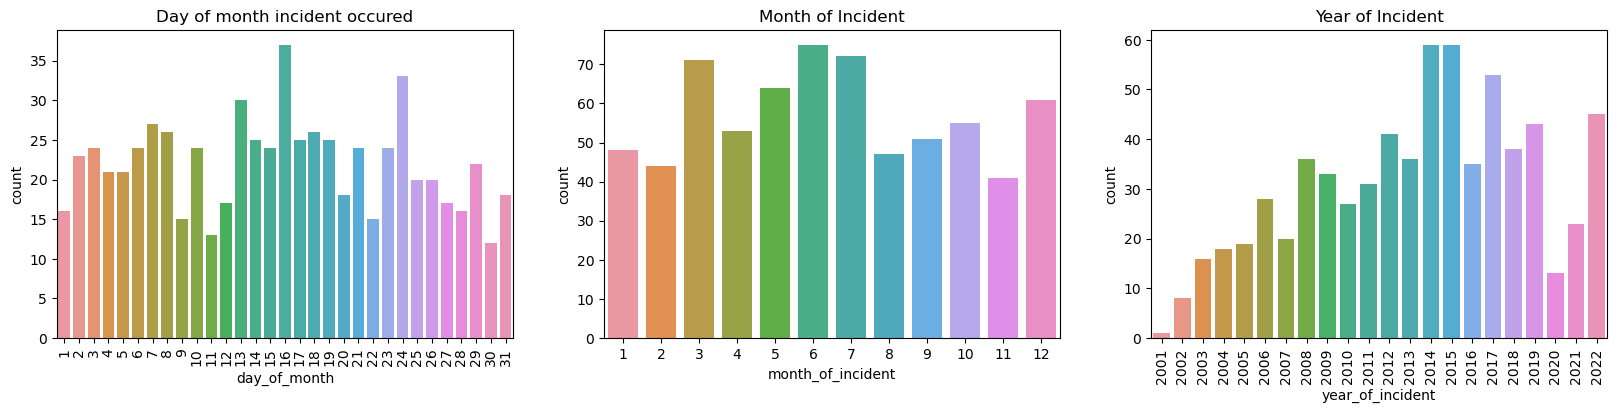

In [19]:
### print bar graphs that show incidents clustered in days of month, month, and years to see if there are any trends
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20,4), sharey=False)

c1 = sns.countplot(x=df['day_of_month'], ax=axes[0])
sns.countplot(x=df['month_of_incident'], ax=axes[1])
c2 = sns.countplot(x=df['year_of_incident'], ax=axes[2])

axes[0].set_title('Day of month incident occured')
axes[1].set_title('Month of Incident')
axes[2].set_title('Year of Incident')

c1.set_xticklabels(c1.get_xticklabels(), rotation=90)
c2.set_xticklabels(c2.get_xticklabels(), rotation=90)
None

In [20]:
df.to_csv('amusement_park_injury.csv', index = False)